# <div style = "font-weight : bold; text-align : center; color : #2DAA9E;">Appliances Energy Prediction </div>

## <span style = " color : #80CBC4;">Import Libraries </span>

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## <span style = " color : #80CBC4;"> Load and Inspect the Data</span>

### <span style = " color : #FFB433;"> Read the dataset :</span>

In [2]:
pd.set_option('display.max_columns', None)  
df = pd.read_csv('data/Energydata.csv')
df.head(5)

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


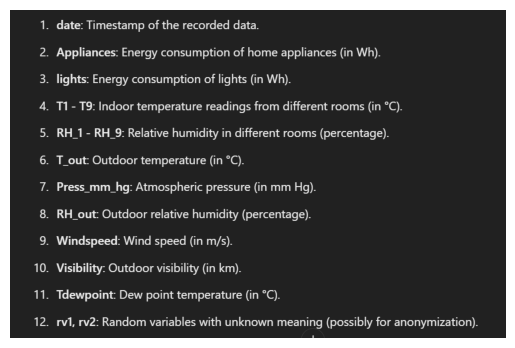

In [3]:
img = mpimg.imread('images/Columns.png')  
plt.imshow(img)
plt.axis('off')  
plt.show()


### <span style = " color : #FFB433;"> Check for missing values :</span>

In [4]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

### <span style = " color : #FFB433;"> Describe the data :</span>

In [5]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,19.592106,50.949283,7.910939,54.609083,20.267106,35.388200,22.029107,42.936165,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,1.844623,9.022034,6.090347,31.149806,2.109993,5.114208,1.956162,5.224361,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,15.330000,29.815000,-6.065000,1.000000,15.390000,23.200000,16.306667,29.600000,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,18.277500,45.400000,3.626667,30.025000,18.700000,31.500000,20.790000,39.066667,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,19.390000,49.090000,7.300000,55.290000,20.033333,34.863333,22.100000,42.375000,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,20.619643,53.663333,11.256000,83.226667,21.600000,39.000000,23.390000,46.536000,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,25.795000,96.321667,28.290000,99.900000,26.000000,51.400000,27.230000,58.780000,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## <span style = " color : #80CBC4;">Data Preprocessing </span>

### <span style = " color : #FFB433;"> Remove unnecessary columns :</span>

In [6]:
df = df.drop(['date','rv1', 'rv2'], axis=1)

### <span style = " color : #FFB433;"> Normalize the data :</span>

In [7]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(data_scaled, columns=df.columns)
df_scaled

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
0,-0.367676,3.301264,-1.118645,1.843821,-0.520411,1.073683,-1.235063,1.686130,-0.908217,1.506438,-1.314903,0.471160,-0.145196,0.951798,-1.453646,1.219861,-1.957509,1.141572,-1.217324,0.958136,-0.152647,-2.976328,0.822080,1.207694,2.091596,0.366975
1,-0.367676,3.301264,-1.118645,1.616807,-0.520411,1.057097,-1.235063,1.704566,-0.908217,1.604528,-1.314903,0.471160,-0.176941,0.945592,-1.453646,1.206825,-1.957509,1.134554,-1.200778,0.965363,-0.174588,-2.962813,0.822080,1.071703,1.766584,0.343135
2,-0.465215,3.301264,-1.118645,1.517959,-0.520411,1.033550,-1.235063,1.748608,-0.944115,1.580918,-1.314903,0.458968,-0.221822,0.916484,-1.453646,1.182057,-1.957509,1.109032,-1.233869,0.950910,-0.196529,-2.949298,0.822080,0.935713,1.441572,0.319294
3,-0.465215,4.561378,-1.118645,1.459321,-0.520411,1.024540,-1.235063,1.769092,-0.962063,1.542526,-1.314903,0.458968,-0.242621,0.925045,-1.485243,1.154030,-2.008631,1.082233,-1.233869,0.926821,-0.218470,-2.935783,0.822080,0.799723,1.116559,0.295454
4,-0.367676,4.561378,-1.118645,1.526336,-0.520411,1.009797,-1.235063,1.769092,-0.962063,1.497991,-1.296832,0.458968,-0.253567,0.972238,-1.453646,1.142298,-2.008631,1.082233,-1.233869,0.926821,-0.240411,-2.922268,0.822080,0.663733,0.791547,0.271613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,0.022483,-0.479080,2.415962,1.583299,2.530318,0.394449,2.458745,0.590209,1.882026,1.511812,1.955947,0.160801,2.772610,-1.721052,2.006168,1.781709,1.365409,1.366295,1.843571,1.261649,2.881489,-0.043599,-1.616282,-0.288198,-1.243314,2.282163
19731,-0.075056,-0.479080,2.374452,1.568221,2.468301,0.407788,2.425512,0.608646,1.882026,1.511812,1.972211,0.152673,2.674091,-1.721052,2.033251,1.764949,1.365409,1.311932,1.843571,1.261649,2.856414,-0.043599,-1.593912,-0.220203,-1.172659,2.274216
19732,1.680659,0.781035,2.374452,1.592514,2.411103,0.576982,2.383971,0.752037,1.882026,1.544061,1.972211,0.146022,2.580498,-1.721052,2.025126,1.762155,1.365409,1.287048,1.843571,1.261649,2.831338,-0.043599,-1.571542,-0.152208,-1.102004,2.266269
19733,3.143756,0.781035,2.374452,1.691361,2.313256,0.642694,2.304213,0.629130,1.882026,1.557883,1.955947,0.138633,2.384554,-1.721052,2.006168,1.741763,1.346238,1.260011,1.843571,1.268273,2.806263,-0.043599,-1.549171,-0.084213,-1.031349,2.258322


### <span style = " color : #FFB433;"> Explore the relationship between features and target variable: :</span>

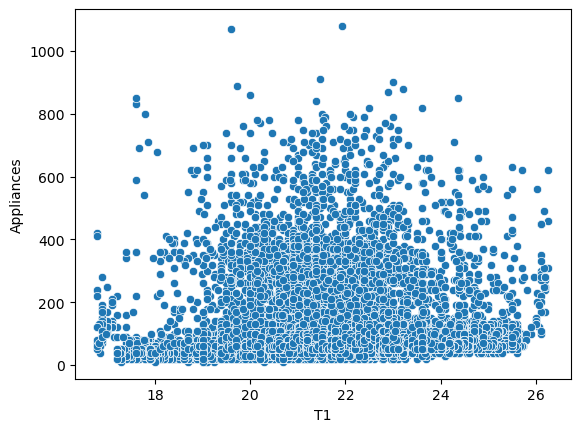

In [8]:
sns.scatterplot(x='T1', y='Appliances', data=df)
plt.show()

In [9]:
corr_matrix = df_scaled.corr()

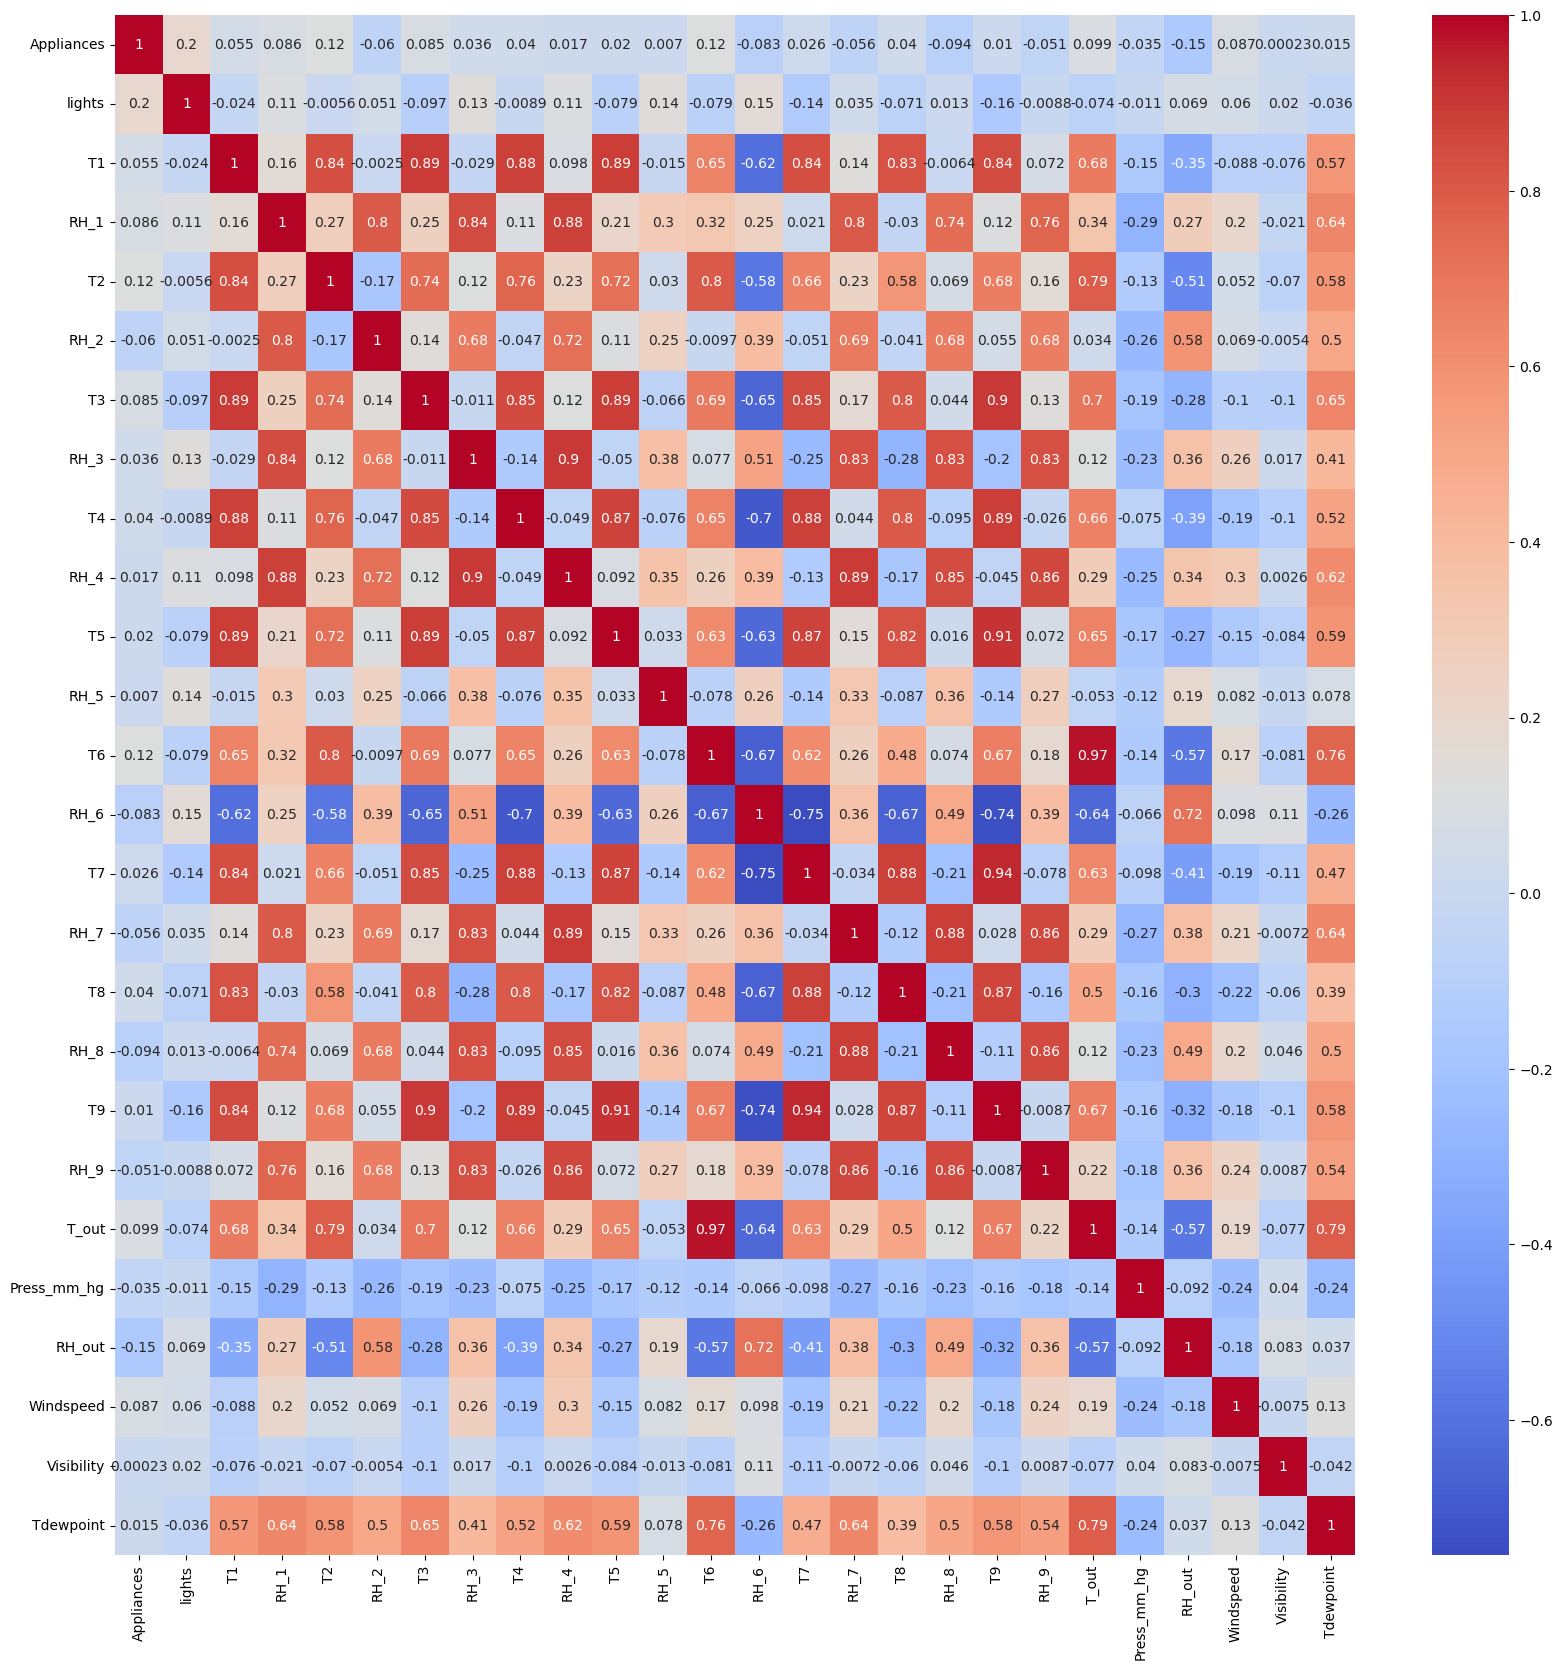

In [10]:
# create the heatmap with a larger size
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)

# show the plot
plt.show()

## <span style = " color : #80CBC4;">Apply PCA </span>

### <span style = " color : #FFB433; "> Calculate the eigenvalues, percentage of inertia, and cumulative percentage : </span>

In [11]:
# Compute the eigenvalues of the correlation matrix
eigenvalues = np.linalg.eigvals(corr_matrix)

# Sort the eigenvalues in descending order
eigenvalues_sorted = np.sort(eigenvalues)[::-1]

# Calculate the percentage of inertia
inertia_percentage = (eigenvalues_sorted / eigenvalues_sorted.sum()) *100

# Calculate the cumulative percentage
cumulative_percentage = np.cumsum(inertia_percentage)

# Display the eigenvalues, percentage of inertia, and cumulative percentage

result_df = pd.DataFrame({
'Eigenvalues': eigenvalues_sorted,
'Percentage of Inertia': inertia_percentage,
'Cumulative Percentage': cumulative_percentage
}, index=range(1, len(eigenvalues_sorted) + 1))

result_df.index.name = 'Component'
result_df.round(2)

,Eigenvalues,Percentage of Inertia,Cumulative Percentage
Component,,,
1,9.33,35.88,35.88
2,7.06,27.17,63.05
3,1.87,7.20,70.24
4,1.27,4.88,75.12
5,1.05,4.02,79.14
6,0.98,3.77,82.91
7,0.91,3.51,86.43
8,0.76,2.91,89.34
9,0.56,2.14,91.49


### <span style = " color : #FFB433; "> Visualize the eigenvalues : </span>

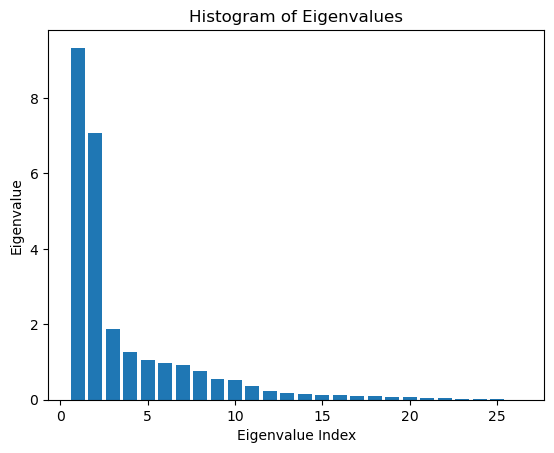

In [12]:
plt.bar(range(1, len(eigenvalues_sorted) + 1), eigenvalues_sorted)
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Histogram of Eigenvalues')
plt.show()

### <span style = " color : #FFB433; "> Compute the principal components : </span>

In [13]:
data = df_scaled.T  
pca = PCA()
pca.fit(data)

PCA()

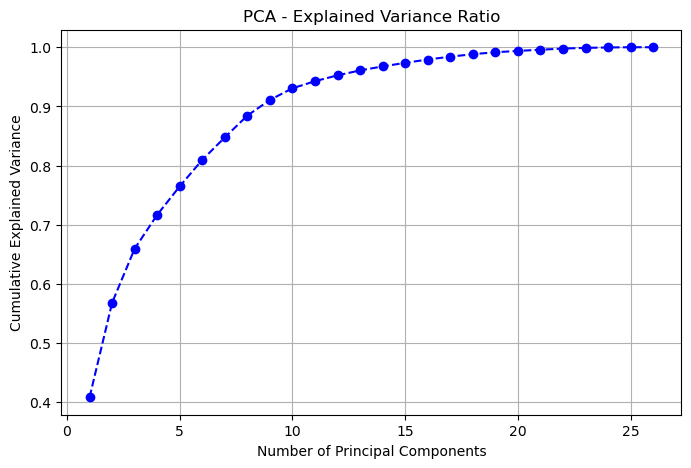

In [14]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance Ratio')
plt.grid()
plt.show()

In [15]:
n_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of components: {n_components}")

Optimal number of components: 12


### <span style = " color : #FFB433; "> Apply PCA : </span>

In [16]:
# Set the n_components = 12
principal = PCA(n_components = 12)
principal.fit(data)
x = principal.transform(data)
pca_df = pd.DataFrame(x, columns=[f'PC{i+1}' for i in range(12)])
 
# Check the dimensions of data after PCA
print(x.shape)

# Display the first few rows
print(pca_df.head())


(26, 12)
         PC1        PC2        PC3        PC4        PC5        PC6  \
0   3.729697  71.366164  54.712868 -55.182441   8.162845 -71.001844   
1  34.353574  78.580146  27.207843 -69.553303 -20.316185  -8.384743   
2 -93.948585  -4.220161 -15.826536  -9.932400  -1.483897  13.951227   
3  55.416220 -60.247573   2.909949 -11.640603  -3.835980 -18.976561   
4 -79.673624 -16.007399  36.552541   1.296767 -15.037806  20.913117   

         PC7        PC8        PC9       PC10       PC11       PC12  
0  20.806714  68.886060  -5.369808   6.816061   9.379085  -3.666320  
1 -67.498922 -60.942168   8.582172  -0.898630  13.272063  -0.595556  
2  -4.775092  -0.975594 -29.310562  -2.972273  -9.958427 -14.441885  
3 -11.741262   8.789353  17.757408 -31.246320 -25.455353  -2.190431  
4 -21.056256  12.766862 -39.773172   7.933445 -23.660181  -4.396316  


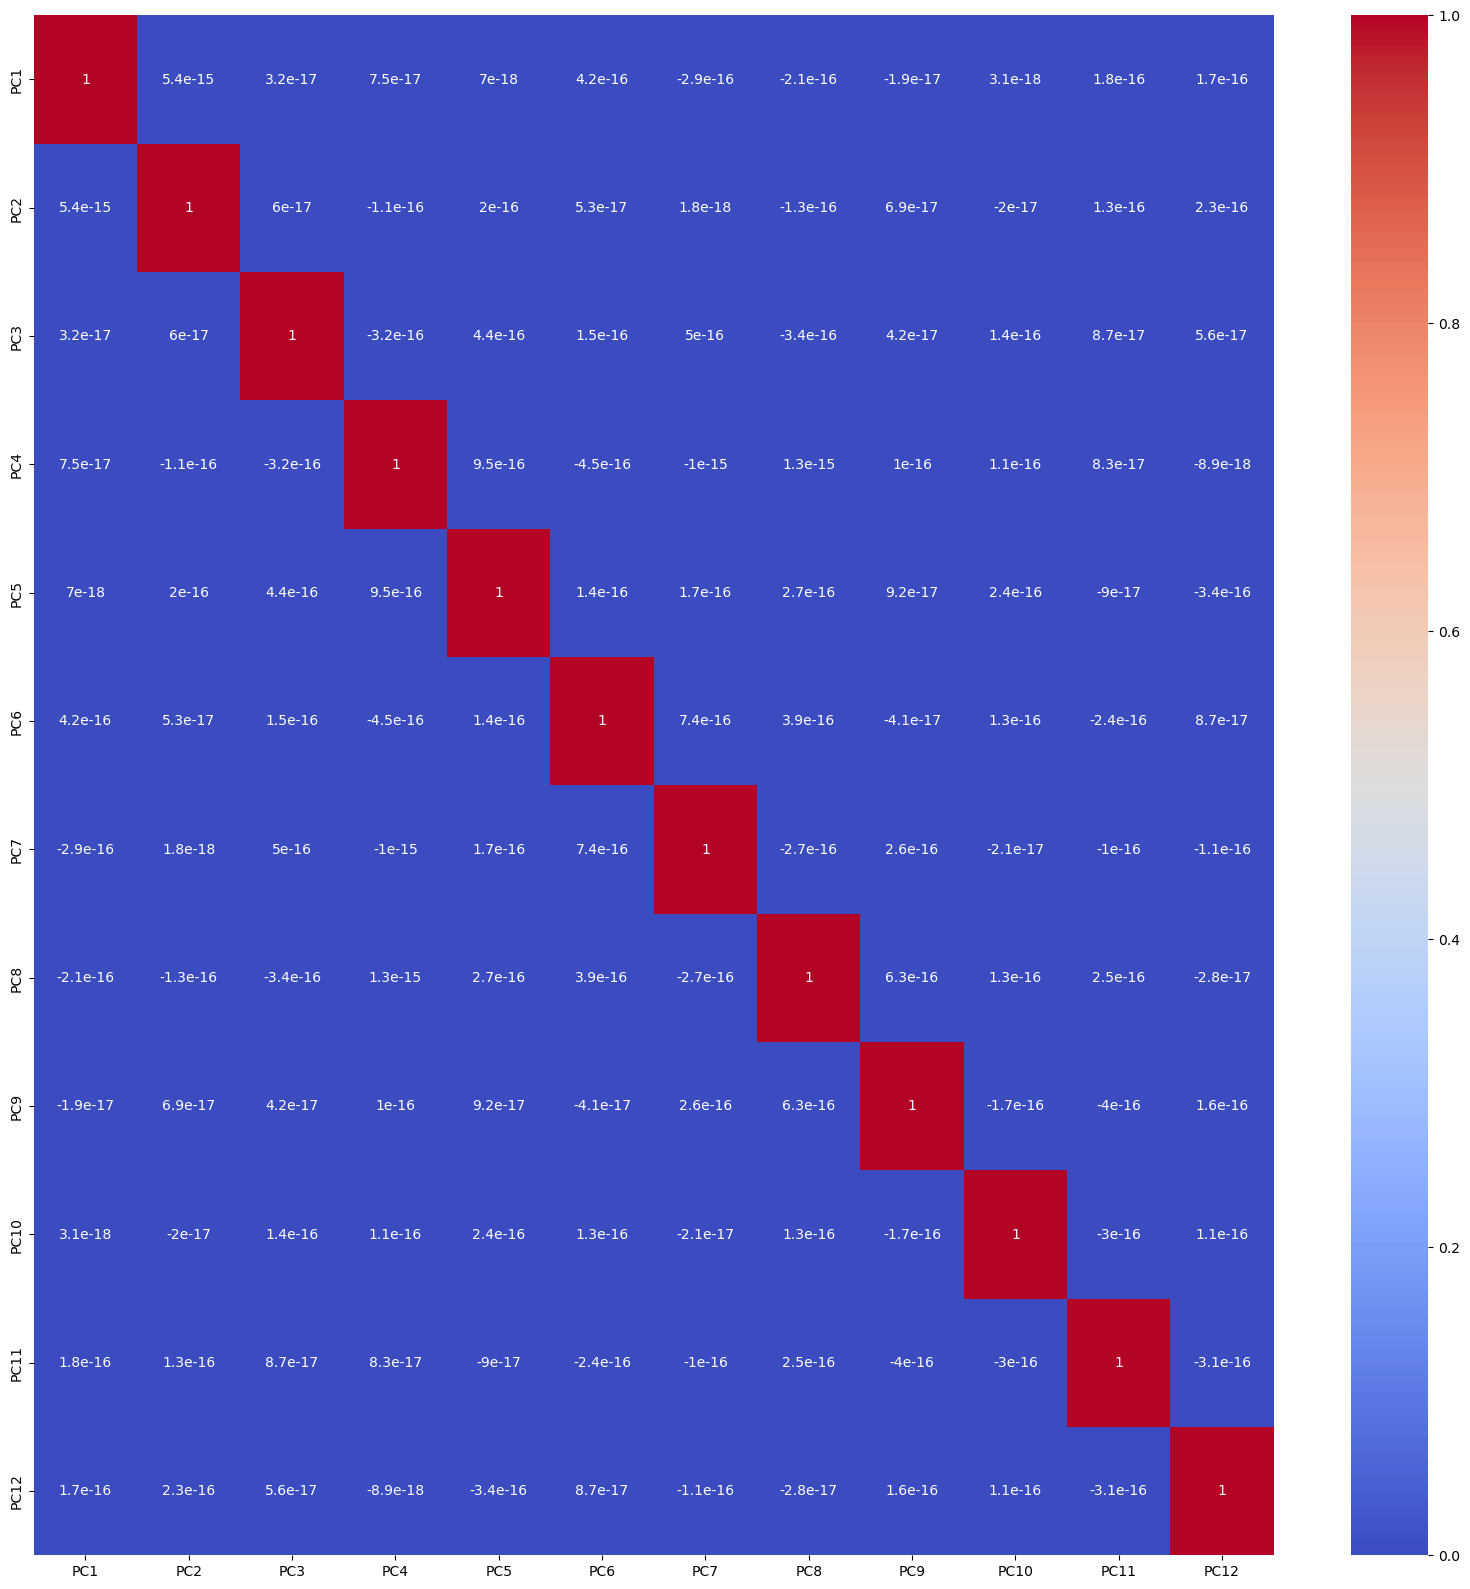

In [17]:
# create the heatmap with a larger size
plt.figure(figsize=(20, 20))
sns.heatmap(pca_df.corr(), cmap='coolwarm', annot=True)

# show the plot
plt.show()

### <span style = " color : #FFB433; ">  Analyze Variance Explained by Components : </span>

In [18]:
# Explained variance by each component
explained_variance = principal.explained_variance_ratio_

# Print variance explained by each component
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var*100:.2f}% variance explained")

PC1: 40.85% variance explained
PC2: 15.98% variance explained
PC3: 9.12% variance explained
PC4: 5.73% variance explained
PC5: 4.81% variance explained
PC6: 4.48% variance explained
PC7: 3.79% variance explained
PC8: 3.69% variance explained
PC9: 2.64% variance explained
PC10: 1.97% variance explained
PC11: 1.20% variance explained
PC12: 0.99% variance explained


### <span style = " color : #FFB433; "> Visualize the PCA Results : </span>

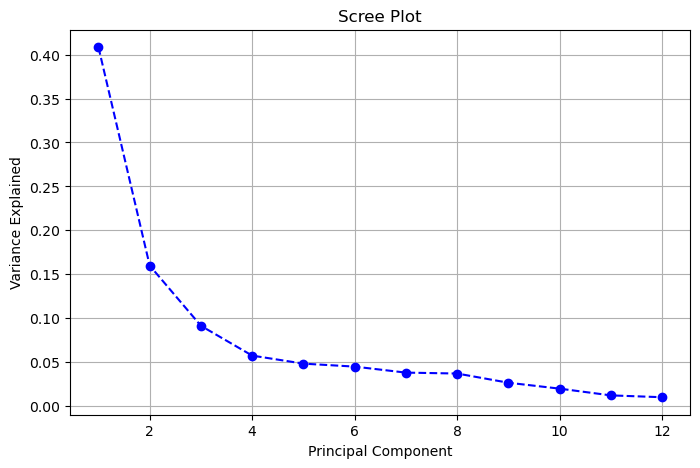

In [19]:
# Plot variance explained
plt.figure(figsize=(8,5))
plt.plot(range(1, 13), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.grid()
plt.show()


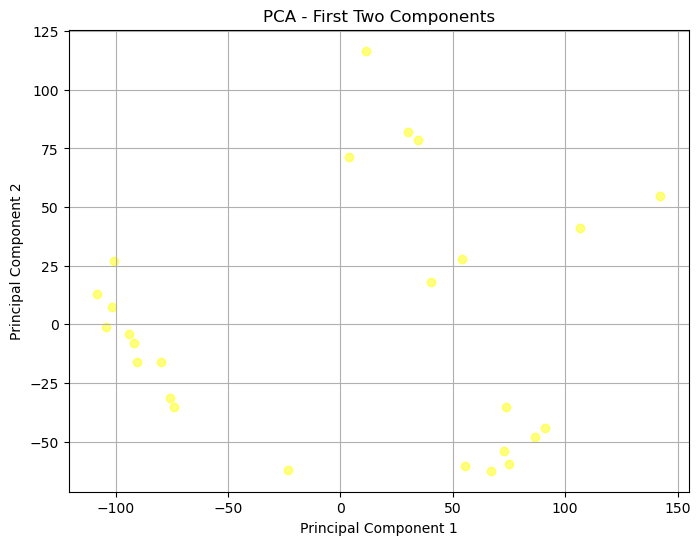

In [20]:
# 2D Visualization of First Two Principal Components
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5, color='yellow')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - First Two Components')
plt.grid()
plt.show()